# Assingment 1 from Renewables in Electricity Markets
### Course 46755, DTU Wind (Technical University of Denmark) - Instructor: Jalal Kazempour

This notebook aims to replicate the Assignment 1 from DTU. It contains explanations on the theory applied, sometimes referring to the course slides

**Case study:** IEEE 24-bus Reliability Test System (Table F.4).

**Goal of Sections 1-5. Step 1:** clear a single-hour, single-node ("copper-plate") electricity market with price-elastic demand, and determine:

1. The market-clearing price under a uniform pricing scheme
2. The social welfare of the system
3. The profit of each producer, including both conventional units and wind farms
4. The utility of each demand
5. Verification of the market-clearing price via the KKT conditions.

**Goal of Section 6 (Step 2)**:

1. Extends Step 1's single-hour copper-plate market to a full 24-hour horizon, adding a storage unit whose charging/discharging decisions link the hours together.
2. Builds synthetic hourly profiles for demand and wind (the IEEE 24-bus data has no hourly values) and solves the same market-clearing LP twice - with and without storage - to compare outcomes directly.
3. Reports the 24-hour social welfare and each producer's/storage's profit, and checks whether the hourly price still equals the marginal generator's offer cost (it does in 22 of 24 hours; in the other 2, storage itself sets the price).


## 1. Imports and input data

The input data (conventional generators, wind farms, demands, transmission lines)
was transcribed from the IEEE 24-bus Reliability Test System technical data table
into `data/Assignment1_IEEE24bus_input_data.xlsx`.


In [1]:
import pandas as pd
import numpy as np
import os
from scipy.optimize import linprog


In [2]:
# From Excel: Assignment 1, IEEE 24-bus input data
data_path = os.path.join("data", "Assignment1_IEEE24bus_input_data.xlsx")
data_file = pd.read_excel(data_path, sheet_name=None)  # returns all sheets as a dict

gens = data_file["Conventional_generators"]
wind = data_file["Wind_farms"]
demands = data_file["Demands"]
lines = data_file["Transmission_lines"]

gens


,Generator,Location_node,Production_cost_USD_per_MWh,Upward_reserve_cost_USD_per_MW,Downward_reserve_cost_USD_per_MW,Capacity_MW,Max_upward_reserve_MW,Max_downward_reserve_MW
0,G1,1,13.32,1.68,2.32,106.4,48,48
1,G2,2,13.32,1.68,2.32,106.4,48,48
2,G3,7,20.70,3.30,4.67,245.0,84,84
3,G4,13,20.93,4.07,3.93,413.7,216,216
4,G5,15,26.11,1.89,3.11,42.0,42,42
5,G6,15,10.52,5.48,3.52,108.5,36,36
6,G7,16,10.52,5.48,3.52,108.5,36,36
7,G8,18,6.02,4.98,5.02,280.0,60,60
8,G9,21,5.47,5.53,4.97,280.0,60,60
9,G10,22,7.00,8.00,6.00,210.0,48,48


## 2. Market-clearing price (copper-plate, single hour)

**Model:** single node ("copper-plate", i.e. the transmission network is ignored),
single hour, price-elastic demand.

**Optimization problem** (Lecture 2, slides 85-89):

$$
\text{Maximize} \quad SW = \sum_{d} U_d \, p_d \; - \; \sum_{g} C_g \, p_g
$$

$$
\text{subject to:} \qquad
0 \le p_g \le \bar{P}_g \quad \forall g
\qquad\qquad
0 \le p_d \le \bar{P}_d \quad \forall d
$$

$$
\sum_{d} p_d \; - \; \sum_{g} p_g \; = \; 0 \;:\; \lambda
$$

where:
- $U_d$ = bid price of demand $d$ [\$/MWh]
- $C_g$ = offer price of producer $g$ [\$/MWh] (conventional generators and wind farms)
- $\bar{P}_g$ = capacity of producer $g$ (or day-ahead forecast for wind) [MW]
- $\bar{P}_d$ = maximum load of demand $d$ [MW]
- $\lambda$ = dual variable of the power-balance constraint = **market-clearing price**

$SW$ is the **social welfare**: the total value created by the market, equal to the
sum of what consumers are willing to pay for the energy they receive, minus the
total cost incurred by producers to generate it. Maximizing $SW$ subject to the
physical/technical limits of every unit is, by the first welfare theorem applied
to this idealized (perfectly competitive, no market power) setting, equivalent to
what a competitive uniform-price auction achieves.


### 2.1 Build the supply side (offer curve)

Producers = conventional generators (offer price = production cost) + wind farms
(offer price = \$0/MWh, quantity = day-ahead forecast, as stated in the assignment).
Wind is offered at zero cost because, once built, producing wind energy has (near)
zero marginal cost - this is what places it first in the merit order.


In [3]:
supplier_names = list(gens["Generator"]) + list(wind["Wind_farm"])
supplier_cost = np.concatenate([
    gens["Production_cost_USD_per_MWh"].to_numpy(),
    np.zeros(len(wind)),
])
supplier_capacity = np.concatenate([
    gens["Capacity_MW"].to_numpy(),
    wind["Day_ahead_forecast_MW"].to_numpy(),
])
n_sup = len(supplier_names)

pd.DataFrame({"supplier": supplier_names, "offer_price": supplier_cost, "capacity_MW": supplier_capacity})


,supplier,offer_price,capacity_MW
0,G1,13.32,106.40
1,G2,13.32,106.40
2,G3,20.70,245.00
3,G4,20.93,413.70
4,G5,26.11,42.00
5,G6,10.52,108.50
6,G7,10.52,108.50
7,G8,6.02,280.00
8,G9,5.47,280.00
9,G10,7.00,210.00


### 2.2 Build the demand side (bid curve)

**Assumption:** the demand bid price is set equal to the curtailment cost
(500 \$/MWh), which is much higher than any generation offer price, as requested
by the assignment ("use comparatively high values relative to the generation
cost of conventional units, to ensure that most demands are supplied"). Economically,
the curtailment cost represents the *Value of Lost Load* (VoLL): the maximum price a
consumer would rationally accept to pay rather than being disconnected, which is
exactly the definition of a demand bid price in an elastic-demand market model.


In [4]:
demand_names = list(demands["Demand"])
demand_bid = demands["Curtailment_cost_USD_per_MWh"].to_numpy()
demand_maxload = demands["Consumption_MW"].to_numpy()
n_dem = len(demand_names)

pd.DataFrame({"demand": demand_names, "bid_price": demand_bid, "max_load_MW": demand_maxload})


,demand,bid_price,max_load_MW
0,D1,500,84
1,D2,500,75
2,D3,500,139
3,D4,500,58
4,D5,500,55
5,D6,500,106
6,D7,500,97
7,D8,500,132
8,D9,500,135
9,D10,500,150


### 2.3 Linear programming formulation

`scipy.optimize.linprog` only **minimizes**, so we minimize $-SW$ instead of
maximizing $SW$:

$$
\text{minimize} \quad \sum_{g} C_g \, p_g \; - \; \sum_{d} U_d \, p_d
$$

The decision vector is $x = [\, p_{sup} \;(n_{sup}) \, , \; p_{dem} \;(n_{dem}) \,]$.
This is a linear program (LP): the objective and every constraint are linear in
$x$, and the feasible region (a box intersected with one hyperplane) is convex,
so any local optimum found is guaranteed to be the **global** optimum.


In [5]:
# Objective vector: minimize sum(C_g * p_g) - sum(U_d * p_d)
c = np.concatenate([supplier_cost, -demand_bid])

# Bounds: 0 <= p_sup <= capacity , 0 <= p_dem <= max load
bounds = [(0, cap) for cap in supplier_capacity] + [(0, load) for load in demand_maxload]

# Power balance equality constraint: sum(p_dem) - sum(p_sup) = 0
A_eq = np.concatenate([-np.ones(n_sup), np.ones(n_dem)]).reshape(1, -1)
b_eq = np.array([0.0])


In [6]:
result = linprog(c=c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")

if not result.success:
    raise RuntimeError(f"Market-clearing LP did not solve: {result.message}")

p_sup_opt = result.x[:n_sup]
p_dem_opt = result.x[n_sup:]

dispatch_gens = pd.Series(p_sup_opt, index=supplier_names, name="Dispatch_MW").round(2)
dispatch_dem = pd.Series(p_dem_opt, index=demand_names, name="Consumption_MW").round(2)

print("Dispatch of producers (MW):")
print(dispatch_gens)
print("\nDispatch of demands (MW):")
print(dispatch_dem)


Dispatch of producers (MW):
G1     106.40
G2     106.40
G3     217.64
G4       0.00
G5       0.00
G6     108.50
G7     108.50
G8     280.00
G9     280.00
G10    210.00
G11    217.00
G12    245.00
W1     120.54
W2     115.52
W3      53.34
W4      38.16
Name: Dispatch_MW, dtype: float64

Dispatch of demands (MW):
D1      84.0
D2      75.0
D3     139.0
D4      58.0
D5      55.0
D6     106.0
D7      97.0
D8     132.0
D9     135.0
D10    150.0
D11    205.0
D12    150.0
D13    245.0
D14     77.0
D15    258.0
D16    141.0
D17    100.0
Name: Consumption_MW, dtype: float64


### 2.4 Market-clearing price

We compute the price in two independent ways, to cross-check the result:

- **Method A:** the dual variable (Lagrange multiplier) of the power-balance
  constraint. Since we minimized $f = -SW$ subject to
  $\big(\sum_d p_d - \sum_{sup} p_{sup}\big) = 0$, we have
  $\dfrac{d(\min f)}{d(b_{eq})} = -\dfrac{d(SW^*)}{d(b_{eq})} = -\lambda
  \;\Rightarrow\; \lambda = -\text{marginal}$.

- **Method B (economic / KKT intuition, Lecture 2 slides 73-77):** the market-clearing
  price equals the offer price of the **marginal producer** - the price-setting
  unit dispatched strictly between 0 and its capacity (neither bound is binding,
  so both of its capacity multipliers are zero by complementary slackness). Section
  4 below derives and checks this rigorously for *every* unit, not just the marginal one.


In [7]:
social_welfare = -result.fun  # result.fun = min(-SW) = -SW*, so SW* = -result.fun

# Method A: dual variable of the power-balance constraint
price_from_dual = -result.eqlin.marginals[0]

# Method B: identify the marginal (price-setting) producer
tol = 1e-6
is_marginal = (p_sup_opt > tol) & (p_sup_opt < supplier_capacity - tol)
marginal_unit = np.array(supplier_names)[is_marginal]
marginal_price = supplier_cost[is_marginal]

print(f"Total social welfare: {social_welfare:,.2f} $")
print(f"Market-clearing price (Method A, dual variable): {price_from_dual:.2f} $/MWh")
print(f"Marginal producer (Method B, KKT check): {marginal_unit} at {marginal_price} $/MWh")


Total social welfare: 1,084,239.43 $
Market-clearing price (Method A, dual variable): 20.70 $/MWh
Marginal producer (Method B, KKT check): ['G3'] at [20.7] $/MWh


## 3. Social welfare, producer profit and demand utility

Once the market-clearing price $\lambda$ and the optimal dispatch
$(p_g^\star, p_d^\star)$ are known, every other economic outcome follows directly.

**Profit of producer $g$** (uniform pricing: every accepted MW is paid the same
price $\lambda$, regardless of the producer's own offer price):

$$
\pi_g \;=\; \underbrace{\lambda \, p_g^\star}_{\text{revenue}} \; - \;
\underbrace{C_g \, p_g^\star}_{\text{cost}} \;=\; (\lambda - C_g)\, p_g^\star
$$

A producer only earns a strictly positive profit if it is *inframarginal*, i.e. if
its offer price $C_g$ is strictly below the market price $\lambda$. Wind farms
(offer price \$0/MWh) are always inframarginal whenever $\lambda > 0$, so they earn
the full market price on every MWh produced - this is the essence of the
**merit-order effect**: cheap/zero-marginal-cost renewables suppress the price and
capture it as pure profit (an "infra-marginal rent").

**Utility of demand $d$** (as defined in the assignment):

$$
u_d \;=\; p_d^\star \, \big( U_d \, - \, \lambda \big)
$$

This is the consumer-side analogue of producer profit: a demand only benefits if
its bid price $U_d$ (its willingness to pay) exceeds the price it actually pays,
$\lambda$.

**Consistency check.** Because the market-clearing problem maximizes
$SW = \sum_d U_d p_d - \sum_g C_g p_g$, and $\lambda \sum_d p_d = \lambda \sum_g p_g$
at the optimum (power balance), the following identity must hold exactly:

$$
SW \;=\; \sum_g \pi_g \; + \; \sum_d u_d
$$

i.e. the social welfare "pie" is split, without any leftover, between producer
profits and consumer utilities. We verify this numerically below.


In [8]:
# Profit of producer g = revenue - cost = (price - offer_price) * dispatched_quantity
producer_profit = (price_from_dual - supplier_cost) * p_sup_opt

# Utility of demand d = consumption * (bid_price - price)
demand_utility = p_dem_opt * (demand_bid - price_from_dual)

producers_summary = pd.DataFrame({
    "Offer_price_USD_per_MWh": supplier_cost,
    "Dispatch_MW": p_sup_opt,
    "Profit_USD": producer_profit,
}, index=supplier_names).round(2)

demands_summary = pd.DataFrame({
    "Bid_price_USD_per_MWh": demand_bid,
    "Consumption_MW": p_dem_opt,
    "Utility_USD": demand_utility,
}, index=demand_names).round(2)

print("Producers: offer price, dispatch and profit")
print(producers_summary)
print("\nDemands: bid price, consumption and utility")
print(demands_summary)


Producers: offer price, dispatch and profit
     Offer_price_USD_per_MWh  Dispatch_MW  Profit_USD
G1                     13.32       106.40      785.23
G2                     13.32       106.40      785.23
G3                     20.70       217.64        0.00
G4                     20.93         0.00       -0.00
G5                     26.11         0.00       -0.00
G6                     10.52       108.50     1104.53
G7                     10.52       108.50     1104.53
G8                      6.02       280.00     4110.40
G9                      5.47       280.00     4264.40
G10                     7.00       210.00     2877.00
G11                    10.52       217.00     2209.06
G12                    10.89       245.00     2403.45
W1                      0.00       120.54     2495.18
W2                      0.00       115.52     2391.26
W3                      0.00        53.34     1104.14
W4                      0.00        38.16      789.91

Demands: bid price, consumption and u

In [9]:
total_profit = producer_profit.sum()
total_utility = demand_utility.sum()

print(f"Sum of producer profits : {total_profit:,.2f} $")
print(f"Sum of demand utilities : {total_utility:,.2f} $")
print(f"Sum of both             : {total_profit + total_utility:,.2f} $")
print(f"Social welfare (SW*)    : {social_welfare:,.2f} $")


Sum of producer profits : 26,424.33 $
Sum of demand utilities : 1,057,815.10 $
Sum of both             : 1,084,239.43 $
Social welfare (SW*)    : 1,084,239.43 $


**Observations:**

- Wind farms (W1-W4) earn the highest profits *per MWh* of any unit, since their
  cost is \$0/MWh, yet they are paid the full market price of 20.70 \$/MWh -
  a direct illustration of the merit-order effect benefiting low-marginal-cost
  renewables.
- The marginal generator (G3) earns **zero profit**: it is paid exactly its own
  offer price (20.70 \$/MWh), so revenue equals cost. This is a general property
  of uniform-price auctions: the price-setting unit never profits from the auction
  itself.
- G4 and G5 are not dispatched (offer price above the market price) and correctly
  show zero profit.
- All 17 demands are served in full (bid price 500 \$/MWh $\gg$ 20.70 \$/MWh), so
  every demand's utility is strictly positive and proportional to its consumption.


## 4. Verifying the market-clearing price via the KKT conditions

The assignment explicitly asks us to **verify** the market-clearing price using
the Karush-Kuhn-Tucker (KKT) conditions, rather than just trusting the LP solver's
output. This section rebuilds the Lagrangian of the minimization problem solved in
Section 2.3 and checks its optimality conditions directly.

**Lagrangian** (Lecture 2, slides 61-71). For our problem,
$\;\text{minimize } f(x)=\sum_g C_g p_g - \sum_d U_d p_d\;$ subject to
$-p_g\le 0$, $p_g-\bar P_g\le 0$, $-p_d\le 0$, $p_d-\bar P_d\le 0$, and
$\sum_d p_d - \sum_g p_g = 0$:

$$
\mathcal{L} = \sum_g C_g p_g - \sum_d U_d p_d
+ \lambda\Big(\sum_d p_d - \sum_g p_g\Big)
+ \sum_g\big[-p_g\,\underline{\mu}_g + (p_g-\bar P_g)\,\overline{\mu}_g\big]
+ \sum_d\big[-p_d\,\underline{\mu}_d + (p_d-\bar P_d)\,\overline{\mu}_d\big]
$$

**Stationarity** ($\partial\mathcal{L}/\partial p_g = 0$ and
$\partial\mathcal{L}/\partial p_d = 0$) gives, for every producer $g$ and demand $d$:

$$
\lambda = C_g - \underline{\mu}_g + \overline{\mu}_g
\qquad\qquad
\lambda = U_d + \underline{\mu}_d - \overline{\mu}_d
$$

**Complementary slackness** requires
$\underline{\mu}_g \, p_g = 0$, $\overline{\mu}_g\,(\bar P_g - p_g) = 0$ (and
likewise for demands), together with dual feasibility
$\underline{\mu}_g,\overline{\mu}_g,\underline{\mu}_d,\overline{\mu}_d \ge 0$.

Because a unit cannot simultaneously be at its lower bound ($p_g=0$) and its upper
bound ($p_g=\bar P_g$) unless $\bar P_g=0$, **at most one** of
$\underline{\mu}_g,\overline{\mu}_g$ can be non-zero. Solving the two
stationarity equations above under this restriction gives closed-form expressions
for the implied multipliers:

$$
\overline{\mu}_g = \max(\lambda - C_g,\, 0), \qquad
\underline{\mu}_g = \max(C_g - \lambda,\, 0)
$$

$$
\overline{\mu}_d = \max(U_d - \lambda,\, 0), \qquad
\underline{\mu}_d = \max(\lambda - U_d,\, 0)
$$

These formulas already guarantee dual feasibility ($\mu \ge 0$ by construction, since
they are defined as a $\max$ with 0). What is **not** automatic is complementary
slackness: we must check numerically that these implied multipliers are only
non-zero when the corresponding bound is actually active. That is what the code
below verifies for every single producer and demand.


In [10]:
# Implied dual variables (only one of each pair can be non-zero, by construction)
mu_sup_up = np.maximum(price_from_dual - supplier_cost, 0.0)   # positive => should be at capacity
mu_sup_low = np.maximum(supplier_cost - price_from_dual, 0.0)  # positive => should be at zero
mu_dem_up = np.maximum(demand_bid - price_from_dual, 0.0)      # positive => should be fully served
mu_dem_low = np.maximum(price_from_dual - demand_bid, 0.0)     # positive => should be at zero

# Complementary-slackness residuals: mu_low * p and mu_up * (Pbar - p) must both be ~0
cs_sup = np.maximum(mu_sup_low * p_sup_opt, mu_sup_up * (supplier_capacity - p_sup_opt))
cs_dem = np.maximum(mu_dem_low * p_dem_opt, mu_dem_up * (demand_maxload - p_dem_opt))

kkt_table = pd.DataFrame({
    "cost_or_bid": np.concatenate([supplier_cost, demand_bid]),
    "dispatch_MW": np.concatenate([p_sup_opt, p_dem_opt]),
    "mu_low": np.concatenate([mu_sup_low, mu_dem_low]),
    "mu_up": np.concatenate([mu_sup_up, mu_dem_up]),
    "complementary_slackness_residual": np.concatenate([cs_sup, cs_dem]),
}, index=supplier_names + demand_names).round(6)

kkt_table


,cost_or_bid,dispatch_MW,mu_low,mu_up,complementary_slackness_residual
G1,13.32,106.40,0.00,7.38,0.0
G2,13.32,106.40,0.00,7.38,0.0
G3,20.70,217.64,0.00,0.00,0.0
G4,20.93,0.00,0.23,0.00,0.0
G5,26.11,0.00,5.41,0.00,0.0
G6,10.52,108.50,0.00,10.18,0.0
G7,10.52,108.50,0.00,10.18,0.0
G8,6.02,280.00,0.00,14.68,0.0
G9,5.47,280.00,0.00,15.23,0.0
G10,7.00,210.00,0.00,13.70,0.0


In [11]:
cs_tol = 1e-3  # numerical tolerance (LP solver precision)
kkt_verified = bool(kkt_table["complementary_slackness_residual"].max() < cs_tol)

print(f"Max complementary-slackness residual: {kkt_table['complementary_slackness_residual'].max():.6f}")
print(f"KKT conditions verified for lambda = {price_from_dual:.2f} $/MWh: {kkt_verified}")


Max complementary-slackness residual: 0.000000
KKT conditions verified for lambda = 20.70 $/MWh: True


**Reading the table:** every unit falls into exactly one of three categories,
consistent with economic intuition:

| Situation | Condition | Implied multipliers |
|---|---|---|
| Not dispatched at all ($p=0$) | offer price / bid price on the "wrong side" of $\lambda$ | one multiplier $>0$, the other $=0$ |
| Fully dispatched ($p=\bar P$) | offer price / bid price on the "right side" of $\lambda$ | one multiplier $>0$, the other $=0$ |
| Marginal (price-setting) unit, $0<p<\bar P$ | offer price $=\lambda$ (or bid price $=\lambda$) | both multipliers $=0$ |

Since every complementary-slackness residual is (numerically) zero, the KKT
conditions confirm - independently of the LP solver's internal dual output - that
**$\lambda = 20.70$ \$/MWh is indeed the market-clearing price**.


## 5. Summary of Step 1 results

| Quantity | Value |
|---|---|
| Market-clearing price | **20.70 \$/MWh** |
| Marginal (price-setting) producer | **G3** (node 7) |
| Total social welfare | **1,084,239.43 \$** |
| Sum of producer profits | see Section 3 |
| Sum of demand utilities | see Section 3 |
| KKT conditions | **verified** (residual < 1e-3) |

Total generation available (conventional + wind, 2690.06 MW) exceeds total demand
(2207 MW), and since every demand bid price (500 \$/MWh) is far above every
generator's offer price, **all 17 demands are served in full** at the optimum, and
generation is dispatched strictly in merit order (cheapest first) until the 2207 MW
of demand is met.


## 6. Step 2: Copper-plate market clearing over 24 hours, with storage

Step 1 cleared a single hour in isolation. Step 2 extends the same idea to a full
day (24 hours, indexed $t = 1, \dots, 24$) and adds a large-scale **energy
storage unit** (e.g. pumped hydro).

**Why this needs one 24-hour optimization problem, not 24 separate ones.** Without
storage, each hour would be entirely independent - exactly 24 copies of Step 1
with different data. Storage breaks that independence: how much it charges in
hour $t$ determines how much energy it has available to discharge in hour
$t+1$, and so on. The market-clearing problem therefore has to be solved
**jointly across all 24 hours at once**.


### 6.1 The storage model

Following the assignment's notation (lowercase = variables, uppercase/Greek =
parameters), the storage unit has two power variables and one energy variable per
hour:

- $p_t^{ch}$, $p_t^{dis}$: charging / discharging power in hour $t$ [MW]
- $e_t$: energy stored in the battery at the end of hour $t$ [MWh]

subject to:

$$
0 \le p_t^{ch} \le P^{ch}, \qquad
0 \le p_t^{dis} \le P^{dis}, \qquad
0 \le e_t \le E \qquad \forall t
$$

$$
e_t = e_{t-1} + p_t^{ch}\,\eta^{ch} - \dfrac{p_t^{dis}}{\eta^{dis}} \qquad \forall t
$$

where $P^{ch}, P^{dis}, E$ are the charging/discharging/energy capacities, and
$\eta^{ch} < \eta^{dis} < 1$ are the charging/discharging efficiencies (assumed
different so that simultaneous charging and discharging is never profitable,
avoiding the need for binary variables - assignment's Note 3).

**Note 2 of the assignment**: the storage submits **zero bid and offer price**.
It therefore does not appear in the objective function at all - only in the
constraints above. Economically, it behaves as a pure **arbitrager**: it does not
care about the absolute price level, only about price *differences between
hours* (charge when cheap, discharge when expensive).

**Chosen parameters** (not part of the IEEE 24-bus data, so - per the
assignment's own instruction - we pick reasonable values on the order of a
mid-sized conventional unit, assignment's Note 1):

| Parameter | Value | Meaning |
|---|---|---|
| $P^{ch}$ | 150 MW | charging capacity |
| $P^{dis}$ | 150 MW | discharging capacity |
| $E$ | 600 MWh | energy capacity (4 hours at full power) |
| $\eta^{ch}$ | 0.90 | charging efficiency |
| $\eta^{dis}$ | 0.95 | discharging efficiency |
| $e_0$ | 300 MWh | energy stored at the start of hour 1 (50% full) |


### 6.2 Building 24-hour profiles

The assignment tells us wind generation and demand (bid price and quantity) vary
hour by hour, but does not give us the actual hourly numbers - so we build
**illustrative, reproducible 24-hour "shape" profiles** (each with a mean of 1)
and apply them to the Step-1 base values: `base_value * shape`.

- **Load shape**: a stylised double-peak daily curve (morning + evening peaks,
  low overnight), built from two Gaussian bumps on top of a flat base load. Used
  for demand quantity, and (compressed to $\pm 15\%$) for demand bid price too,
  since the assignment asks for bids to be "comparatively higher during peak
  hours".
- **Wind shape**: wind is not tied to the time of day the way load is, so we
  generate a smooth but non-trivial profile with a **seeded random walk**
  (reproducible run to run), clipped so it never collapses to zero or explodes.

Both are written as small functions rather than one-off code, since the same
shapes will likely be reused in later steps of this assignment (e.g. Step 5's
balancing market also needs an hourly wind profile).


In [12]:
def make_daily_load_profile(hours, morning_peak=9, evening_peak=19, spread=3.0,
                             base=0.6, morning_weight=0.4, evening_weight=0.5):
    """Stylized double-peak daily electricity demand shape (morning + evening
    peaks, low overnight), as two Gaussian bumps on top of a flat base load."""
    profile = (
        base
        + morning_weight * np.exp(-0.5 * ((hours - morning_peak) / spread) ** 2)
        + evening_weight * np.exp(-0.5 * ((hours - evening_peak) / spread) ** 2)
    )
    return profile / profile.mean()


def make_wind_profile(n_hours, seed=1, volatility=0.15, low=0.2, high=1.6):
    """Smooth but non-trivial 24-hour wind-availability shape: a seeded random
    walk (reproducible), clipped so it never collapses to 0 or explodes."""
    rng = np.random.default_rng(seed)
    steps = rng.normal(loc=0.0, scale=volatility, size=n_hours)
    walk = 1.0 + np.cumsum(steps - steps.mean())
    walk = np.clip(walk, low, high)
    return walk / walk.mean()


T = 24
hours = np.arange(1, T + 1)

load_shape = make_daily_load_profile(hours)
wind_shape = make_wind_profile(T)
bid_price_shape = 1.0 + 0.15 * (load_shape - 1.0)


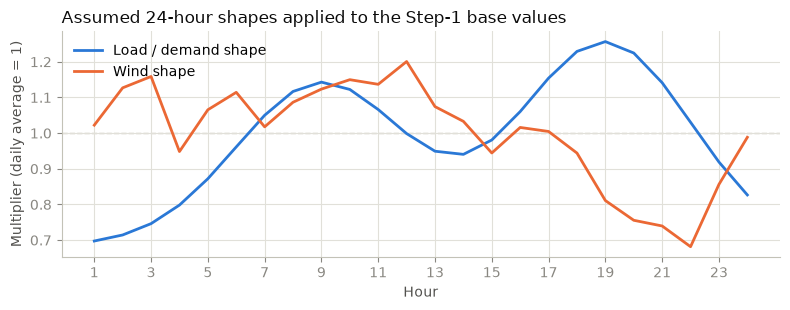

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(hours, load_shape, color="#2a78d6", linewidth=2, label="Load / demand shape")
ax.plot(hours, wind_shape, color="#eb6834", linewidth=2, label="Wind shape")
ax.axhline(1.0, color="#c3c2b7", linewidth=1, linestyle="--", zorder=0)
ax.set_xlabel("Hour", color="#52514e")
ax.set_ylabel("Multiplier (daily average = 1)", color="#52514e")
ax.set_title("Assumed 24-hour shapes applied to the Step-1 base values", color="#0b0b0b", loc="left")
ax.set_xticks(range(1, 25, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.tick_params(colors="#898781")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


### 6.3 Applying the profiles, and the multi-hour LP

Conventional generator capacity does **not** vary by hour (only wind and demand
do, per the assignment), so it is simply repeated 24 times.

**Optimization problem** (natural 24-hour extension of Step 1's, plus the
storage constraints from Section 6.1):

$$
\text{Maximize} \quad SW = \sum_{t=1}^{24}\Big(\sum_{d} U_{d,t}\,p_{d,t} \;-\; \sum_{g} C_g\,p_{g,t}\Big)
$$

$$
\text{subject to, for every hour } t:\qquad
0 \le p_{g,t} \le \bar P_g, \qquad 0 \le p_{d,t} \le \bar P_{d,t}
$$

$$
\sum_{d} p_{d,t} + p_t^{ch} \;-\; \sum_{g} p_{g,t} \;-\; p_t^{dis} \;=\; 0 \;:\; \lambda_t
$$

plus the storage constraints of Section 6.1 (with dual variables of their own,
which we do not need for this step). Charging behaves like an extra demand,
discharging like an extra producer - both at a zero bid/offer price. The dual
variable $\lambda_t$ of each hour's power-balance constraint is that hour's
**market-clearing price**, exactly as in Step 1.

We implement this as **one function**, `solve_multi_hour_market(...)`, instead of
writing the LP twice. Passing $P^{ch}=P^{dis}=E=0$ removes storage entirely (its
own bounds force $p^{ch}=p^{dis}=e=0$ in every hour), so calling the *same*
function once with the real storage parameters and once with all-zero storage
parameters gives us a like-for-like **"with storage" vs. "without storage"**
comparison - solved by the exact same market logic both times.


In [14]:
supplier_capacity_th = np.zeros((n_sup, T))
supplier_capacity_th[: len(gens), :] = gens["Capacity_MW"].to_numpy()[:, None]
supplier_capacity_th[len(gens):, :] = wind["Day_ahead_forecast_MW"].to_numpy()[:, None] * wind_shape[None, :]

demand_bid_th = demand_bid[:, None] * bid_price_shape[None, :]
demand_maxload_th = demand_maxload[:, None] * load_shape[None, :]

# Storage (pumped-hydro-like) parameters - see Section 6.1
P_ch_max = 150.0
P_dis_max = 150.0
E_max = 600.0
eta_ch = 0.90
eta_dis = 0.95
e0 = 0.5 * E_max


In [15]:
def solve_multi_hour_market(supplier_cost, supplier_capacity_th, demand_bid_th, demand_maxload_th,
                             P_ch_max, P_dis_max, E_max, eta_ch, eta_dis, e0):
    """Clear a T-hour copper-plate market with one storage unit.

    Passing P_ch_max = P_dis_max = E_max = 0 removes storage from the market (its
    own bounds then force p_ch = p_dis = e = 0 in every hour), so this same
    function solves both the "with storage" and "without storage" cases.
    """
    n_sup, T = supplier_capacity_th.shape
    n_dem = demand_bid_th.shape[0]

    # Variable layout: [ p_sup (n_sup*T) | p_dem (n_dem*T) | p_ch (T) | p_dis (T) | e (T) ]
    i_sup = 0
    i_dem = i_sup + n_sup * T
    i_ch = i_dem + n_dem * T
    i_dis = i_ch + T
    i_e = i_dis + T
    n_var = i_e + T

    c = np.concatenate([
        np.repeat(supplier_cost, T),
        -demand_bid_th.flatten(),
        np.zeros(3 * T),
    ])

    bounds = (
        [(0, cap) for cap in supplier_capacity_th.flatten()]
        + [(0, load) for load in demand_maxload_th.flatten()]
        + [(0, P_ch_max)] * T
        + [(0, P_dis_max)] * T
        + [(0, E_max)] * T
    )

    A_eq = np.zeros((2 * T, n_var))
    b_eq = np.zeros(2 * T)

    for t in range(T):
        # Power balance in hour t: sum_d p_d,t + p_ch,t = sum_g p_g,t + p_dis,t : lambda_t
        A_eq[t, i_sup + t: i_sup + n_sup * T: T] = -1.0
        A_eq[t, i_dem + t: i_dem + n_dem * T: T] = 1.0
        A_eq[t, i_ch + t] = 1.0
        A_eq[t, i_dis + t] = -1.0

        # Storage energy balance in hour t: e_t = e_{t-1} + eta_ch*p_ch,t - p_dis,t/eta_dis
        row = T + t
        A_eq[row, i_e + t] = 1.0
        A_eq[row, i_ch + t] = -eta_ch
        A_eq[row, i_dis + t] = 1.0 / eta_dis
        if t == 0:
            b_eq[row] = e0
        else:
            A_eq[row, i_e + t - 1] = -1.0

    result = linprog(c=c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    if not result.success:
        raise RuntimeError(f"Multi-hour market-clearing LP did not solve: {result.message}")

    price_t = -result.eqlin.marginals[:T]

    return {
        "p_sup": result.x[i_sup:i_dem].reshape(n_sup, T),
        "p_dem": result.x[i_dem:i_ch].reshape(n_dem, T),
        "p_ch": result.x[i_ch:i_dis],
        "p_dis": result.x[i_dis:i_e],
        "e": result.x[i_e:i_e + T],
        "price_t": price_t,
        "social_welfare": -result.fun,
    }


with_storage = solve_multi_hour_market(
    supplier_cost, supplier_capacity_th, demand_bid_th, demand_maxload_th,
    P_ch_max, P_dis_max, E_max, eta_ch, eta_dis, e0,
)
without_storage = solve_multi_hour_market(
    supplier_cost, supplier_capacity_th, demand_bid_th, demand_maxload_th,
    P_ch_max=0.0, P_dis_max=0.0, E_max=0.0, eta_ch=eta_ch, eta_dis=eta_dis, e0=0.0,
)

prices_table = pd.DataFrame({
    "Hour": hours,
    "Price_with_storage": with_storage["price_t"],
    "Price_without_storage": without_storage["price_t"],
})
prices_table["Price_difference"] = prices_table["Price_with_storage"] - prices_table["Price_without_storage"]
prices_table.round(2)


,Hour,Price_with_storage,Price_without_storage,Price_difference
0,1,10.89,10.89,0.00
1,2,10.89,10.89,0.00
2,3,10.89,10.89,0.00
3,4,13.32,13.32,0.00
4,5,13.32,13.32,0.00
5,6,20.70,20.70,0.00
6,7,20.93,20.93,0.00
7,8,20.93,20.93,0.00
8,9,20.93,20.93,0.00
9,10,20.93,20.93,0.00


### 6.4 Hourly prices, with vs. without storage

Two headline numbers summarize the comparison:


In [16]:
print(f"Total social welfare with storage:    {with_storage['social_welfare']:,.2f} $")
print(f"Total social welfare without storage: {without_storage['social_welfare']:,.2f} $")
print(f"Welfare gain from adding storage:      {with_storage['social_welfare'] - without_storage['social_welfare']:,.2f} $")

price_range_with = with_storage["price_t"].max() - with_storage["price_t"].min()
price_range_without = without_storage["price_t"].max() - without_storage["price_t"].min()
print(f"\nPrice spread with storage:    {price_range_with:.2f} $/MWh "
      f"(min {with_storage['price_t'].min():.2f}, max {with_storage['price_t'].max():.2f})")
print(f"Price spread without storage: {price_range_without:.2f} $/MWh "
      f"(min {without_storage['price_t'].min():.2f}, max {without_storage['price_t'].max():.2f})")


Total social welfare with storage:    26,115,774.98 $
Total social welfare without storage: 25,968,393.39 $
Welfare gain from adding storage:      147,381.59 $

Price spread with storage:    15.22 $/MWh (min 10.89, max 26.11)
Price spread without storage: 508.36 $/MWh (min 10.89, max 519.25)


**What happened:** in the *without-storage* baseline, hours 18-20 (the evening
peak) show prices jumping to roughly 500-520 \$/MWh - two orders of magnitude
above every other hour. That is the signature of **load curtailment**: at those
hours, available generation (conventional + wind) is not enough to meet demand,
so some demand goes unserved and the price is set by that unserved demand's own
(very high) bid price, instead of by a generator's offer price.

With storage in the picture, the price spread collapses from roughly 500 \$/MWh
down to about 15 \$/MWh. The storage unit charges overnight/off-peak (hours 1-3,
when it is cheapest) and discharges exactly during the evening peak (hours
7, 10, 18-20), effectively **shifting energy from low-price hours to high-price
hours** - a textbook illustration of **peak shaving / valley filling**, and the
reason total social welfare is higher with storage (it relieves scarcity at the
peak instead of curtailing demand).


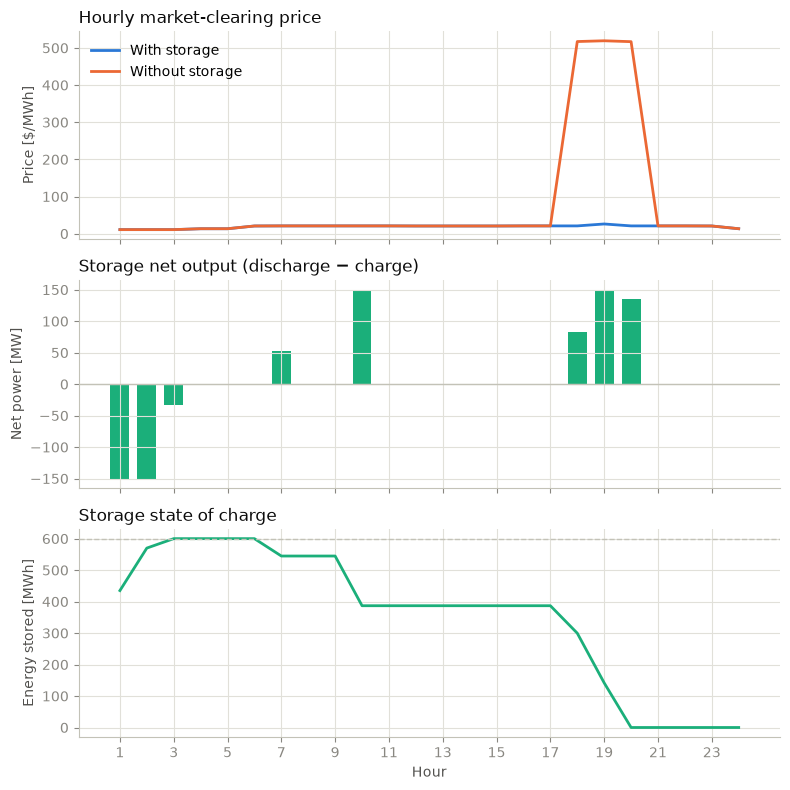

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(hours, with_storage["price_t"], color="#2a78d6", linewidth=2, label="With storage")
axes[0].plot(hours, without_storage["price_t"], color="#eb6834", linewidth=2, label="Without storage")
axes[0].set_ylabel("Price [$/MWh]", color="#52514e")
axes[0].set_title("Hourly market-clearing price", color="#0b0b0b", loc="left")
axes[0].legend(frameon=False, loc="upper left")

axes[1].bar(hours, with_storage["p_dis"] - with_storage["p_ch"], color="#1baf7a", width=0.7)
axes[1].axhline(0.0, color="#c3c2b7", linewidth=1)
axes[1].set_ylabel("Net power [MW]", color="#52514e")
axes[1].set_title("Storage net output (discharge $-$ charge)", color="#0b0b0b", loc="left")

axes[2].plot(hours, with_storage["e"], color="#1baf7a", linewidth=2)
axes[2].axhline(E_max, color="#c3c2b7", linewidth=1, linestyle="--")
axes[2].set_ylabel("Energy stored [MWh]", color="#52514e")
axes[2].set_xlabel("Hour", color="#52514e")
axes[2].set_title("Storage state of charge", color="#0b0b0b", loc="left")

for ax in axes:
    ax.set_xticks(range(1, 25, 2))
    ax.grid(True, color="#e1e0d9", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#c3c2b7")
    ax.tick_params(colors="#898781")

fig.tight_layout()
plt.show()


### 6.5 Profit of each producer and of the storage unit, over 24 hours

The same profit/utility formulas from Step 1 apply hour by hour; summed over the
horizon, they become simple matrix operations (which is why we write them as
small reusable functions rather than a 24-iteration loop):

$$
\pi_g = \sum_{t=1}^{24} (\lambda_t - C_g)\, p_{g,t}
\qquad\qquad
u_d = \sum_{t=1}^{24} p_{d,t}\, (U_{d,t} - \lambda_t)
$$

**Storage profit** follows the same uniform-pricing logic, but with *zero* cost
instead of $C_g$ (Note 2): it is paid $\lambda_t$ for every MWh it discharges,
and pays $\lambda_t$ for every MWh it charges:

$$
\pi^{storage} = \sum_{t=1}^{24} \lambda_t \,\big(p_t^{dis} - p_t^{ch}\big)
$$

This is a **temporal arbitrager**: it buys energy when $\lambda_t$ is low and
resells it when $\lambda_t$ is high, symmetric to the "spatial arbitrager" role
a congested transmission line plays between two nodes (Lecture 3) - just moving
energy across time instead of across space.


In [18]:
def total_profit_over_horizon(price_t, cost, dispatch_gt):
    """Total profit of each producer over T hours: sum_t (price_t - cost) * dispatch_g,t."""
    return dispatch_gt @ price_t - cost * dispatch_gt.sum(axis=1)


def total_utility_over_horizon(price_t, bid_dt, dispatch_dt):
    """Total utility of each demand over T hours: sum_t dispatch_d,t * (bid_d,t - price_t)."""
    return (dispatch_dt * bid_dt).sum(axis=1) - dispatch_dt @ price_t


producer_profit_24h = total_profit_over_horizon(with_storage["price_t"], supplier_cost, with_storage["p_sup"])
demand_utility_24h = total_utility_over_horizon(with_storage["price_t"], demand_bid_th, with_storage["p_dem"])
storage_profit_24h = float(with_storage["price_t"] @ (with_storage["p_dis"] - with_storage["p_ch"]))

producers_summary_24h = pd.DataFrame({
    "Offer_price_USD_per_MWh": supplier_cost,
    "Total_dispatch_MWh": with_storage["p_sup"].sum(axis=1),
    "Total_profit_USD": producer_profit_24h,
}, index=supplier_names).round(2)

print("Producers: total dispatch and profit over 24 hours (with storage)")
print(producers_summary_24h)
print(f"\nTotal storage profit over 24 hours: {storage_profit_24h:,.2f} $")


Producers: total dispatch and profit over 24 hours (with storage)
     Offer_price_USD_per_MWh  Total_dispatch_MWh  Total_profit_USD
G1                     13.32             1935.49          14978.99
G2                     13.32             2075.50          14978.99
G3                     20.70             3619.85           1945.30
G4                     20.93             2759.93           2142.97
G5                     26.11               37.24              0.00
G6                     10.52             2604.00          21774.87
G7                     10.52             2604.00          21774.87
G8                      6.02             6720.00          86433.20
G9                      5.47             6720.00          90129.20
G10                     7.00             5040.00          59885.70
G11                    10.52             5208.00          43549.73
G12                    10.89             5545.88          46993.45
W1                      0.00             2892.96          54126

In [19]:
total_profit = producer_profit_24h.sum()
total_utility = demand_utility_24h.sum()

print(f"Sum of producer profits : {total_profit:,.2f} $")
print(f"Sum of demand utilities : {total_utility:,.2f} $")
print(f"Storage profit          : {storage_profit_24h:,.2f} $")
print(f"Sum of all three        : {total_profit + total_utility + storage_profit_24h:,.2f} $")
print(f"Social welfare (with storage) : {with_storage['social_welfare']:,.2f} $")


Sum of producer profits : 551,671.57 $
Sum of demand utilities : 25,555,026.31 $
Storage profit          : 9,077.10 $
Sum of all three        : 26,115,774.98 $
Social welfare (with storage) : 26,115,774.98 $


### 6.6 Is the price always equal to the marginal producer's offer price?

In Step 1 we saw the price always equals the offer price of whichever producer
is dispatched strictly between 0 and its capacity. With storage in the picture,
does that still hold in **every** hour? We repeat the same "marginal unit" check
from Step 1, hour by hour.


In [20]:
tol = 1e-6
price_matches_generator = np.zeros(T, dtype=bool)
for t in range(T):
    dispatch_t = with_storage["p_sup"][:, t]
    capacity_t = supplier_capacity_th[:, t]
    marginal_t = (dispatch_t > tol) & (dispatch_t < capacity_t - tol)
    if marginal_t.any():
        price_matches_generator[t] = bool(np.any(np.isclose(supplier_cost[marginal_t], with_storage["price_t"][t], atol=1e-2)))

check_table = pd.DataFrame({
    "Hour": hours,
    "Price": with_storage["price_t"].round(2),
    "Matches_a_generator_cost": price_matches_generator,
    "Storage_charging_MW": with_storage["p_ch"].round(2),
    "Storage_discharging_MW": with_storage["p_dis"].round(2),
    "Energy_stored_MWh": with_storage["e"].round(2),
})
print(f"Hours where the price does NOT match any generator's offer price: {int((~price_matches_generator).sum())} / {T}")
check_table


Hours where the price does NOT match any generator's offer price: 2 / 24


,Hour,Price,Matches_a_generator_cost,Storage_charging_MW,Storage_discharging_MW,Energy_stored_MWh
0,1,10.89,True,150.00,0.00,435.00
1,2,10.89,True,150.00,0.00,570.00
2,3,10.89,True,33.33,0.00,600.00
3,4,13.32,True,0.00,-0.00,600.00
4,5,13.32,True,0.00,0.00,600.00
5,6,20.70,True,0.00,0.00,600.00
6,7,20.93,True,0.00,52.44,544.80
7,8,20.93,True,0.00,0.00,544.80
8,9,20.93,True,0.00,0.00,544.80
9,10,20.93,True,0.00,150.00,386.90


**Finding: no, not in every hour.** In 22 of the 24 hours the price still equals
a generator's offer price, exactly as in Step 1. But in **hours 18 and 20**, the
price does **not** match any generator's cost - and in both of those hours,
storage is discharging at a level *strictly between* 0 and its 150 MW limit
(neither bound is active). By the same complementary-slackness logic as Step 1,
whenever a unit's dispatch is strictly interior, **that unit is the marginal,
price-setting one** - so in hours 18 and 20, it is the *storage unit itself*,
not any generator, that sets the price.

Contrast this with **hour 19**: storage discharges at its full 150 MW limit
(bound is active), so storage is *not* marginal there, and the price
(26.11 \$/MWh) again equals a generator's offer price (G5, the most expensive
unit, is the one filling the remaining gap).

**Why this happens, intuitively:** storage does not bid a cost - it bids
*nothing* (Note 2) - so when it is genuinely the marginal unit, the price is not
pinned to a discrete offer price from our data table at all. Instead it is
pinned by storage's own **intertemporal trade-off**: the value of one more MWh
discharged now must equal the value of the extra MWh available to charge back
later (accounting for the round-trip efficiency loss $\eta^{ch}\eta^{dis}<1$).
That trade-off is exactly a shadow price on the storage's own energy-balance
constraint (Eq. 4) - a "water value" - and deriving it formally, from the
storage owner's own profit-maximization problem and its KKT conditions, is
precisely what **Step 4** of this assignment asks us to do next.


### 6.7 Summary of Step 2 results

| Quantity | Value |
|---|---|
| Total social welfare, with storage | **26,115,774.98 \$** |
| Total social welfare, without storage | 25,968,393.39 \$ |
| Welfare gain from adding storage | **147,381.59 \$** |
| Price spread, with storage | 15.22 \$/MWh (10.89 - 26.11) |
| Price spread, without storage | 508.36 \$/MWh (10.89 - 519.25), due to curtailment at hours 18-20 |
| Total storage profit over 24h | 9,077.10 \$ |
| Hours where price $\ne$ any generator's cost | 2 / 24 (hours 18 and 20 - storage sets the price) |

**Take-aways:** adding storage to this system (i) raises social welfare by
relieving an evening-peak scarcity event that would otherwise force costly load
curtailment, (ii) dramatically compresses the daily price spread (peak shaving /
valley filling), and (iii) occasionally becomes the price-setting unit itself,
breaking the simple "price = marginal generator's cost" rule that held in every
hour of Step 1.
